Test accuracy: 1.000


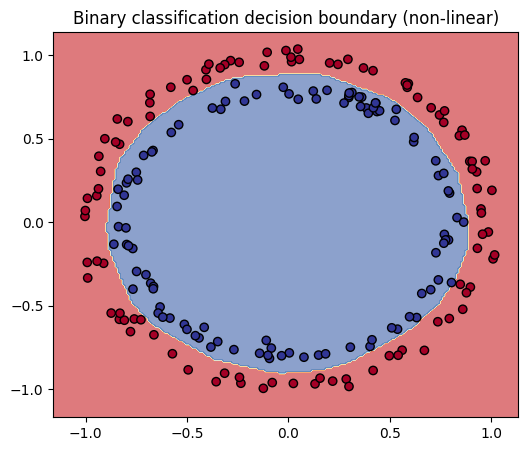

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
tf.keras.layers.Input(shape=(2,)),
tf.keras.layers.Dense(16, activation="relu"),
tf.keras.layers.Dense(16, activation="relu"),
tf.keras.layers.Dense(1, activation="sigmoid")
])
# 2) COMPILE
model.compile(
loss="binary_crossentropy",
optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
metrics=["accuracy"]
)
# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=0)
# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")
# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title("Binary classification decision boundary (non-linear)")
plt.show()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Test accuracy: 0.8842999935150146
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


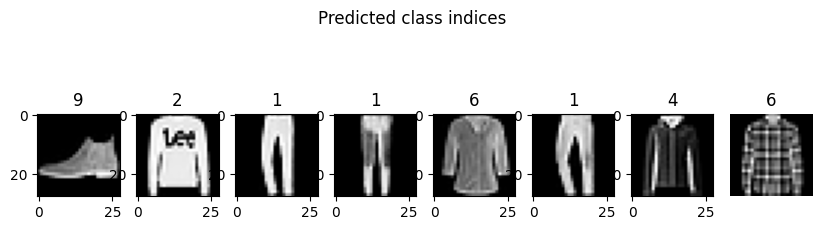

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import ssl
# Load Fashion-MNIST
ssl._create_default_https_context = ssl._create_unverified_context
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0
# 1) CREATE (flatten > Dense ReLU > Dense softmax)
model = tf.keras.Sequential([
tf.keras.layers.Input(shape=(28, 28)),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(128, activation="relu"),
tf.keras.layers.Dense(10, activation="softmax")
])
# 2) COMPILE
model.compile(
loss="sparse_categorical_crossentropy", # labels are ints, not one-hot
optimizer="adam",
metrics=["accuracy"]
)
# 3) FIT
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0)
# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)
# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1)
plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(int(preds[i]))
plt.axis('off')
plt.suptitle("Predicted class indices"); plt.show()